# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026 — posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit — including a machine's — is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$ — except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs — on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants — and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

Files found: [PosixPath('../../labs/03/data/siyaoxu2.csv'), PosixPath('../../labs/02/data/siyaoxu2.csv'), PosixPath('../../labs/01/data/siyaoxu2.csv')]


,x,y,sigma_y
0,0.002556,32.854363,2.598993
1,0.108342,39.629421,2.665560
2,0.336907,35.803217,2.757728
3,0.726326,37.602260,1.479095
4,1.007156,36.786551,2.144997
5,1.185109,39.117330,2.020757
6,1.462885,41.528858,2.022183
7,1.691423,41.830805,1.613247
8,1.701229,42.246468,1.947195
9,1.849294,40.864333,1.026204


Index(['x', 'y', 'sigma_y'], dtype='object')


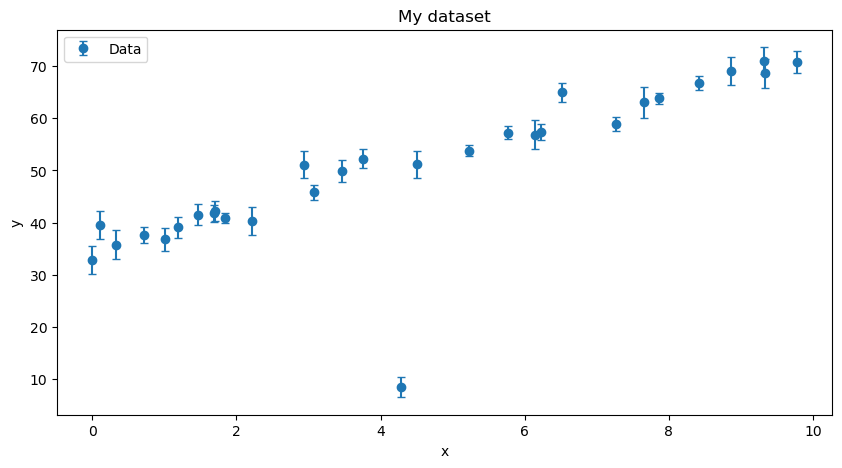

m = 3.7543 +/- 0.1111
b = 33.7363 +/- 0.6052


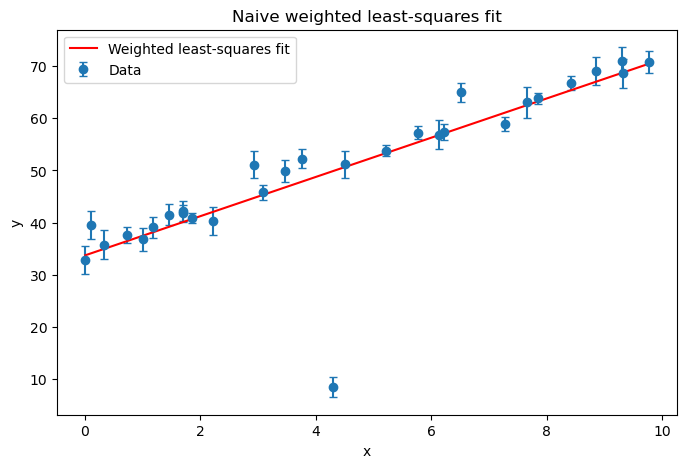

chi-squared = 509.7554
degrees of freedom = 28
reduced chi-squared = 18.2055


In [1]:
# Part 1: your work here
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

netid = "siyaoxu2"
matches = list(Path("../..").rglob(f"{netid}.csv"))

print("Files found:", matches)

data_path = Path("../../labs/01/data/siyaoxu2.csv")
data = pd.read_csv(data_path)


display(data)
print(data.columns)

x = data["x"].to_numpy()
y = data["y"].to_numpy()
sigma_y = data["sigma_y"].to_numpy()

plt.figure(figsize=(10, 5))

plt.errorbar(
    x,
    y,
    yerr=sigma_y,
    fmt="o",
    capsize=3,
    label="Data"

)

plt.xlabel("x")
plt.ylabel("y")
plt.title("My dataset")
plt.legend()
plt.show()

from scipy.optimize import curve_fit

def line_model(x, m, b):
    return m * x + b

parameters, covariance = curve_fit(
    line_model,
    x,
    y,
    sigma=sigma_y,
    absolute_sigma=True
)

m, b = parameters

sigma_m = np.sqrt(covariance[0, 0])
sigma_b = np.sqrt(covariance[1, 1])

print(f"m = {m:.4f} +/- {sigma_m:.4f}")
print(f"b = {b:.4f} +/- {sigma_b:.4f}")

x_plot = np.linspace(x.min(), x.max(), 500)
y_plot = line_model(x_plot, m, b)

plt.figure(figsize=(8, 5))

plt.errorbar(
    x,
    y,
    yerr=sigma_y,
    fmt="o",
    capsize=3,
    label="Data"
)

plt.plot(
    x_plot,
    y_plot,
    color="red",
    label="Weighted least-squares fit"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Naive weighted least-squares fit")
plt.legend()
plt.show()

y_fit = line_model(x, m, b)

chi_squared = np.sum(((y - y_fit) / sigma_y) ** 2)

degrees_of_freedom = len(x) - 2
reduced_chi_squared = chi_squared / degrees_of_freedom

print(f"chi-squared = {chi_squared:.4f}")
print(f"degrees of freedom = {degrees_of_freedom}")
print(f"reduced chi-squared = {reduced_chi_squared:.4f}")

**ANSWER (a few sentences):**

The naive weighted least-squares fit gives m = 3.7543 +/- 0.1111 and b = 33.7363 +/- 0.6052 . The reduced chi-squared = 18.2055, which is much larger than one. This means that the scatter around the fitted line is much larger than expected from the reported sigma_y values. This occurs because the dataset contains outliers, while the naive model treats every point as coming from the same Gaussian error distribution. Therefore, I would not trust the reported error bars as a complete description of the dataset, nor would I fully trust the formal uncertainties on m and b from this naive fit.

## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment — this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer** — one set of numbers
you'd put in a paper — and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

Iteration 1: keeping 28 points, removing 2 points
Iteration 2: keeping 28 points, removing 2 points
Sigma clipping converged.
m = 3.6575 +/- 0.1120
b = 35.1224 +/- 0.6085
Kept points = 28
Removed points = 2
Reduced chi-square = 0.8451


,x,y,sigma_y
15,4.290290,8.489329,1.920159
21,6.512827,64.926543,1.757054


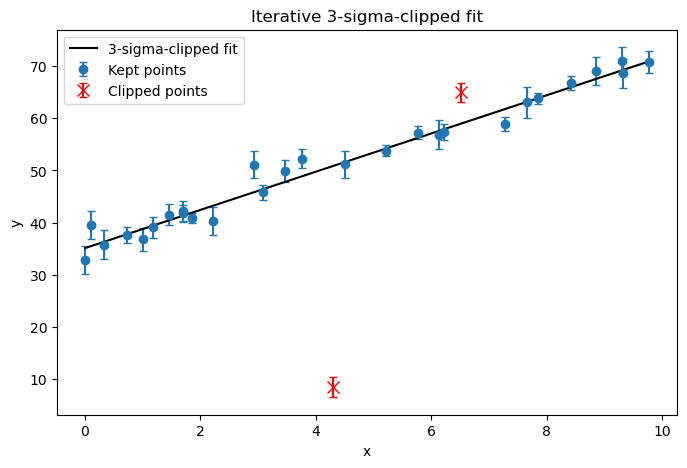

In [2]:
# Part 2: your work here

# Method 1: sigma clipping

clip_threshold = 3.0

keep = np.ones(len(x), dtype=bool)

for iteration in range(20):

    current_parameters, current_covariance = curve_fit(
        line_model,
        x[keep],
        y[keep],
        sigma=sigma_y[keep],
        absolute_sigma=True
    )

    current_m, current_b = current_parameters

    normalized_residuals = (
        y - line_model(x, current_m, current_b)
    ) / sigma_y

    new_keep = keep & (
        np.abs(normalized_residuals) <= clip_threshold
    )

    print(
        f"Iteration {iteration + 1}: "
        f"keeping {new_keep.sum()} points, "
        f"removing {(~new_keep).sum()} points"
    )

    if np.array_equal(new_keep, keep):
        print("Sigma clipping converged.")
        break

    keep = new_keep

clip_parameters, clip_covariance = curve_fit(
    line_model,
    x[keep],
    y[keep],
    sigma=sigma_y[keep],
    absolute_sigma=True
)

m_clip, b_clip = clip_parameters

sigma_m_clip = np.sqrt(clip_covariance[0, 0])
sigma_b_clip = np.sqrt(clip_covariance[1, 1])

clip_residuals = (
    y[keep] - line_model(x[keep], m_clip, b_clip)
) / sigma_y[keep]

clip_chi_squared = np.sum(clip_residuals**2)
clip_dof = keep.sum() - 2
clip_reduced_chi_squared = clip_chi_squared / clip_dof

print(f"m = {m_clip:.4f} +/- {sigma_m_clip:.4f}")
print(f"b = {b_clip:.4f} +/- {sigma_b_clip:.4f}")
print(f"Kept points = {keep.sum()}")
print(f"Removed points = {(~keep).sum()}")
print(f"Reduced chi-square = {clip_reduced_chi_squared:.4f}")

display(data.loc[~keep])

x_clip_plot = np.linspace(x.min(), x.max(), 500)
y_clip_plot = line_model(x_clip_plot, m_clip, b_clip)

plt.figure(figsize=(8, 5))

plt.errorbar(
    x[keep],
    y[keep],
    yerr=sigma_y[keep],
    fmt="o",
    capsize=3,
    label="Kept points"
)

plt.errorbar(
    x[~keep],
    y[~keep],
    yerr=sigma_y[~keep],
    fmt="x",
    color="red",
    capsize=3,
    markersize=9,
    label="Clipped points"
)

plt.plot(
    x_clip_plot,
    y_clip_plot,
    color="black",
    label="3-sigma-clipped fit"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Iterative 3-sigma-clipped fit")
plt.legend()
plt.show()

Optimization successful: True
Successful starting guesses: 4
m = 3.7016
b = 35.1114
outlier fraction = 0.0333
bad distribution mean = 8.4900
bad distribution sigma = 6.0644
minimum allowed bad sigma = 6.0644


,x,y,sigma_y,outlier_probability
15,4.290290,8.489329,1.920159,1.000000e+00
0,0.002556,32.854363,2.598993,2.172807e-05
2,0.336907,35.803217,2.757728,3.261167e-06
4,1.007156,36.786551,2.144997,1.141894e-06
1,0.108342,39.629421,2.665560,7.277258e-07
10,2.218765,40.363194,2.701372,2.528650e-07
3,0.726326,37.602260,1.479095,1.559490e-07
5,1.185109,39.117330,2.020757,1.148558e-07
6,1.462885,41.528858,2.022183,1.954132e-08
9,1.849294,40.864333,1.026204,9.770399e-09


Successful bootstraps = 300 / 300
Mixture m = 3.7016 +/- 0.1134
Mixture b = 35.1114 +/- 0.5286
Outlier fraction = 0.0333 +/- 0.0327


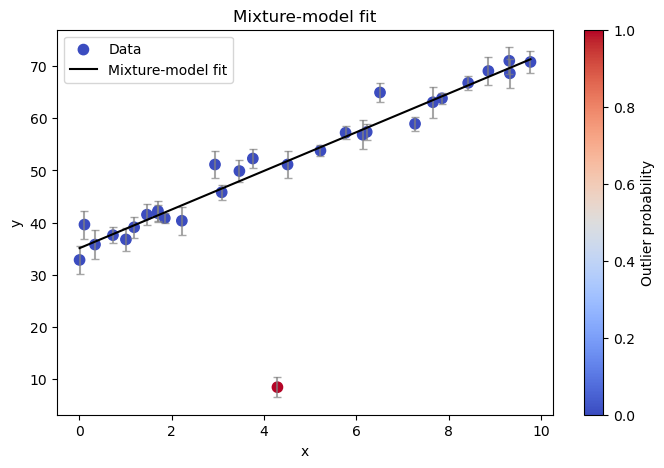

In [3]:
# Method 2: A mixture model

from scipy.optimize import minimize
from scipy.stats import norm
from scipy.special import logsumexp

def mixture_log_components(
    parameters,
    x_data,
    y_data,
    sigma_data
):
    m_value, b_value, f_out, bad_mean, bad_sigma = parameters

    line_mean = line_model(x_data, m_value, b_value)

    log_good = (
        np.log1p(-f_out)
        + norm.logpdf(
            y_data,
            loc=line_mean,
            scale=sigma_data
        )
    )

    bad_scale = np.sqrt(
        sigma_data**2 + bad_sigma**2
    )

    log_bad = (
        np.log(f_out)
        + norm.logpdf(
            y_data,
            loc=bad_mean,
            scale=bad_scale
        )
    )

    return log_good, log_bad


def mixture_nll(
    parameters,
    x_data,
    y_data,
    sigma_data
):
    log_good, log_bad = mixture_log_components(
        parameters,
        x_data,
        y_data,
        sigma_data
    )

    total_log_probability = logsumexp(
        np.column_stack([log_good, log_bad]),
        axis=1
    )

    return -np.sum(total_log_probability)


y_range = np.ptp(y)

minimum_bad_sigma = 3 * np.median(sigma_y)

if np.any(~keep):
    bad_y_start = y[~keep]
else:
    bad_y_start = y

initial_fraction = np.clip(
    (~keep).sum() / len(x),
    0.01,
    0.49
)

initial_bad_mean = np.mean(bad_y_start)

initial_bad_sigma = max(
    np.std(bad_y_start),
    minimum_bad_sigma
)

initial_guesses = [
    [
        m_clip,
        b_clip,
        initial_fraction,
        initial_bad_mean,
        initial_bad_sigma
    ],
    [
        m_clip,
        b_clip,
        0.10,
        np.median(y),
        max(y_range / 2, minimum_bad_sigma)
    ],
    [
        m_clip,
        b_clip,
        0.10,
        y.min(),
        max(y_range / 4, minimum_bad_sigma)
    ],
    [
        m_clip,
        b_clip,
        0.10,
        y.max(),
        max(y_range / 4, minimum_bad_sigma)
    ]
]

bounds = [
    (None, None),                            
    (None, None),                             
    (0.0001, 0.5),                            
    (y.min() - y_range, y.max() + y_range), 
    (minimum_bad_sigma, 10 * y_range)
]

trial_results = []

for guess in initial_guesses:

    result = minimize(
        mixture_nll,
        guess,
        args=(x, y, sigma_y),
        method="L-BFGS-B",
        bounds=bounds
    )

    if result.success and np.isfinite(result.fun):
        trial_results.append(result)

if len(trial_results) == 0:
    raise RuntimeError("All mixture-model optimizations failed.")

mixture_result = min(
    trial_results,
    key=lambda result: result.fun
)

m_mix, b_mix, f_out, bad_mean, bad_sigma = (
    mixture_result.x
)

print("Optimization successful:", mixture_result.success)
print("Successful starting guesses:", len(trial_results))
print(f"m = {m_mix:.4f}")
print(f"b = {b_mix:.4f}")
print(f"outlier fraction = {f_out:.4f}")
print(f"bad distribution mean = {bad_mean:.4f}")
print(f"bad distribution sigma = {bad_sigma:.4f}")
print(f"minimum allowed bad sigma = {minimum_bad_sigma:.4f}")

log_good, log_bad = mixture_log_components(
    mixture_result.x,
    x,
    y,
    sigma_y
)

log_total = logsumexp(
    np.column_stack([log_good, log_bad]),
    axis=1
)

outlier_probability = np.exp(
    log_bad - log_total
)

outlier_table = data.copy()

outlier_table["outlier_probability"] = (
    outlier_probability
)

display(
    outlier_table.sort_values(
        "outlier_probability",
        ascending=False
    )
)

rng = np.random.default_rng(457)

number_of_bootstraps = 300
bootstrap_parameters = []

for bootstrap_number in range(number_of_bootstraps):

    bootstrap_indices = rng.integers(
        0,
        len(x),
        len(x)
    )

    x_boot = x[bootstrap_indices]
    y_boot = y[bootstrap_indices]
    sigma_boot = sigma_y[bootstrap_indices]

    bootstrap_result = minimize(
        mixture_nll,
        mixture_result.x,
        args=(x_boot, y_boot, sigma_boot),
        method="L-BFGS-B",
        bounds=bounds
    )

    if (
        bootstrap_result.success
        and np.all(np.isfinite(bootstrap_result.x))
    ):
        bootstrap_parameters.append(
            bootstrap_result.x
        )

bootstrap_parameters = np.asarray(
    bootstrap_parameters
)

if len(bootstrap_parameters) < 2:
    raise RuntimeError(
        "Too few successful bootstrap fits."
    )

sigma_m_mix = np.std(
    bootstrap_parameters[:, 0],
    ddof=1
)

sigma_b_mix = np.std(
    bootstrap_parameters[:, 1],
    ddof=1
)

sigma_f_out = np.std(
    bootstrap_parameters[:, 2],
    ddof=1
)

print(
    f"Successful bootstraps = "
    f"{len(bootstrap_parameters)} / "
    f"{number_of_bootstraps}"
)

print(
    f"Mixture m = "
    f"{m_mix:.4f} +/- {sigma_m_mix:.4f}"
)

print(
    f"Mixture b = "
    f"{b_mix:.4f} +/- {sigma_b_mix:.4f}"
)

print(
    f"Outlier fraction = "
    f"{f_out:.4f} +/- {sigma_f_out:.4f}"
)


x_mix_plot = np.linspace(
    x.min(),
    x.max(),
    500
)

y_mix_plot = line_model(
    x_mix_plot,
    m_mix,
    b_mix
)

plt.figure(figsize=(8, 5))

plt.errorbar(
    x,
    y,
    yerr=sigma_y,
    fmt="none",
    ecolor="gray",
    alpha=0.7,
    capsize=3
)

points = plt.scatter(
    x,
    y,
    c=outlier_probability,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    s=55,
    label="Data"
)

plt.plot(
    x_mix_plot,
    y_mix_plot,
    color="black",
    label="Mixture-model fit"
)

colorbar = plt.colorbar(points)
colorbar.set_label("Outlier probability")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Mixture-model fit")
plt.legend()
plt.show()

**FINAL ANSWER:** $m = $ 3.7 $\pm$ 0.11 , $b = $ 35.11 $\pm$ 0.53 , outlier fraction $\approx$ 0.033

**Justification and uncertainty method (a short paragraph):**

The iterative sigma-clipping method removed two of the 30 data points and gave m = 3.6575+-0.1120 and b = 35.1224+-0.6085, with a reduced chi-square of 0.8451. The mixture model gave m = 3.7016+-0.1134, b = 35.1114+-0.5286, and an estimated outlier fraction of 0.0333. The two methods give consistent line parameters, but I adopt the mixture-model result because it treats outlier membership probabilistically rather than making a hard rejection at a chosen threshold. I estimated the final uncertainties using the standard deviations of the fitted parameters from 300 nonparametric bootstrap resamples. I also required the outlier component to have a scatter of at least three times the median reported uncertainty so that it remained broader than the inlier distribution; the fitted width reached this limit, so the width of the outlier population itself is not well constrained.

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong — in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset — show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1:*
The AI does not use the given measurement uncertainties. The AI fits the line with np.polyfit(x, y, 1, cov=True), but it does not include sigma y. This means that it treats every data point as equally reliable, even though some points have larger uncertainties than others. After using the AI’s outlier mask, the unweighted fit gives (m=3.6993) and (b=35.3802). A weighted fit using the same 29 points gives (m=3.7016) and (b=35.1114). The difference is not very large in this dataset, but the ai’s method still does not match the measurement information provided. The correct method should give more weight to points with smaller sigma y and less weight to points with larger sigma y.

*Flaw 2:*
The AI uses the wrong method to find outliers. The AI finds outliers by calculating three times the standard deviation of the raw residuals. However, the extreme outlier makes the residual standard deviation very large, giving a threshold of 23.8495 in y units. Because the threshold is so large, the AI removes only point 15. It also ignores the fact that each point has a different sigma y. A better method divides each residual by its own sigma y. With this method, point 15 is (-21.54\sigma) from the weighted fit, and point 21 is (+3.84\sigma) away. Therefore, iterative sigma clipping removes both points. After repeating the fit until no more points are removed, the result is (m=3.6575+-0.1120), (b=35.1224+-0.6085), and reduced （chi^2=0.8451). The correct method is to use normalized residuals, refit the line, and repeat until the result stops changing.

*Flaw 3:*
The AI forces the reduced chi-square to equal one. After removing one outlier, the AI gets a reduced chi^2 of 1.2480. It then multiplies every sigma y by (√1.2480=1.1171). This automatically makes the new reduced chi-square equal 1.000. Therefore, the new value does not prove that the model fits the data well; it only shows that the AI changed the error bars until it obtained the result it wanted. The AI also increases the uncertainties on (m) and (b) again, even though np.polyfit(..., cov=True) has already used the residual scatter when calculating them. It reports uncertainties of 0.1439 for (m) and 0.7814 for (b), while the mixture-model bootstrap gives 0.1134 and 0.5286. The correct approach is to keep the reported sigma y values, handle the outliers using a consistent method, and estimate the parameter uncertainties from the correct model or from bootstrap resampling.

FLAW 1: IGNORING SIGMA_Y
AI unweighted fit: m = 3.6993, b = 35.3802
Weighted fit on the same points: m = 3.7016, b = 35.1114

FLAW 2: INCORRECT OUTLIER REJECTION
AI raw-residual threshold = 23.8495
Indices removed by AI: [15]
Indices removed by iterative normalized clipping: [15 21]


,x,y,sigma_y,normalized_residual
15,4.290290,8.489329,1.920159,-21.536717
21,6.512827,64.926543,1.757054,3.835537



FLAW 3: FORCING REDUCED CHI-SQUARE TO ONE
Original reduced chi-square = 1.2480
Artificial scale factor = 1.1171
Reduced chi-square after rescaling = 1.0000
AI rescaled uncertainties: sigma_m = 0.1439, sigma_b = 0.7814
Mixture bootstrap uncertainties: sigma_m = 0.1134, sigma_b = 0.5286


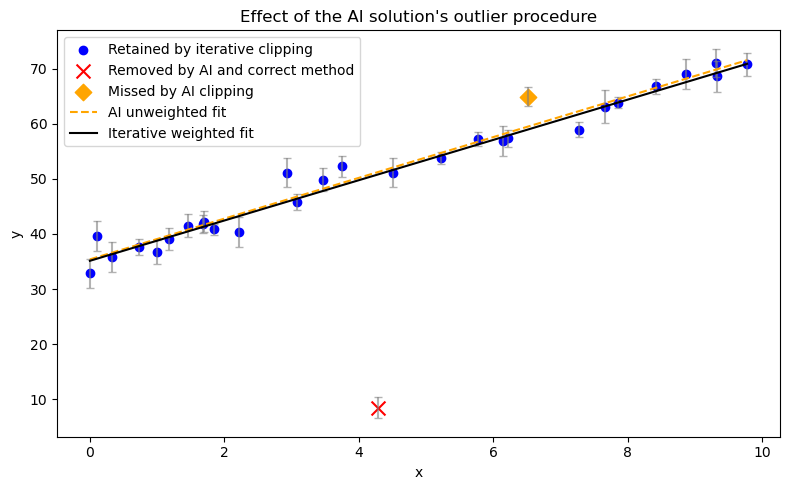

In [4]:
# Part 3: demonstrations here

ai_coefficients, ai_covariance = np.polyfit(
    x,
    y,
    1,
    cov=True
)

ai_m_initial, ai_b_initial = ai_coefficients

ai_residuals = (
    y - line_model(x, ai_m_initial, ai_b_initial)
)

ai_threshold = 3 * np.std(ai_residuals)

ai_mask = np.abs(ai_residuals) < ai_threshold

ai_clean_coefficients, ai_clean_covariance = np.polyfit(
    x[ai_mask],
    y[ai_mask],
    1,
    cov=True
)

ai_m_clean, ai_b_clean = ai_clean_coefficients

ai_m_error, ai_b_error = np.sqrt(
    np.diag(ai_clean_covariance)
)

weighted_coefficients, weighted_covariance = np.polyfit(
    x[ai_mask],
    y[ai_mask],
    1,
    w=1 / sigma_y[ai_mask],
    cov="unscaled"
)

weighted_m, weighted_b = weighted_coefficients

weighted_m_error, weighted_b_error = np.sqrt(
    np.diag(weighted_covariance)
)

print("FLAW 1: IGNORING SIGMA_Y")

print(
    f"AI unweighted fit: "
    f"m = {ai_m_clean:.4f}, "
    f"b = {ai_b_clean:.4f}"
)

print(
    f"Weighted fit on the same points: "
    f"m = {weighted_m:.4f}, "
    f"b = {weighted_b:.4f}"
)

print()

normalized_residuals = (
    y - line_model(x, m, b)
) / sigma_y

correct_outlier_mask = (
    np.abs(normalized_residuals) > 3
)

print("FLAW 2: INCORRECT OUTLIER REJECTION")

print(
    f"AI raw-residual threshold = "
    f"{ai_threshold:.4f}"
)

print(
    "Indices removed by AI:",
    np.where(~ai_mask)[0]
)

print(
    "Indices removed by iterative normalized clipping:",
    np.where(~keep)[0]
)

outlier_comparison = data.copy()

outlier_comparison["normalized_residual"] = (
    normalized_residuals
)

display(
    outlier_comparison.loc[correct_outlier_mask]
)

print()


ai_clean_residuals = (
    y[ai_mask]
    - line_model(
        x[ai_mask],
        ai_m_clean,
        ai_b_clean
    )
)

ai_chi_squared = np.sum(
    (
        ai_clean_residuals
        / sigma_y[ai_mask]
    )**2
)

ai_degrees_of_freedom = ai_mask.sum() - 2

ai_reduced_chi_squared = (
    ai_chi_squared
    / ai_degrees_of_freedom
)

ai_scale_factor = np.sqrt(
    ai_reduced_chi_squared
)

sigma_y_scaled = sigma_y * ai_scale_factor

forced_reduced_chi_squared = np.sum(
    (
        ai_clean_residuals
        / sigma_y_scaled[ai_mask]
    )**2
) / ai_degrees_of_freedom

ai_m_error_scaled = (
    ai_m_error * ai_scale_factor
)

ai_b_error_scaled = (
    ai_b_error * ai_scale_factor
)

print("FLAW 3: FORCING REDUCED CHI-SQUARE TO ONE")

print(
    f"Original reduced chi-square = "
    f"{ai_reduced_chi_squared:.4f}"
)

print(
    f"Artificial scale factor = "
    f"{ai_scale_factor:.4f}"
)

print(
    f"Reduced chi-square after rescaling = "
    f"{forced_reduced_chi_squared:.4f}"
)

print(
    f"AI rescaled uncertainties: "
    f"sigma_m = {ai_m_error_scaled:.4f}, "
    f"sigma_b = {ai_b_error_scaled:.4f}"
)

print(
    f"Mixture bootstrap uncertainties: "
    f"sigma_m = {sigma_m_mix:.4f}, "
    f"sigma_b = {sigma_b_mix:.4f}"
)

missed_by_ai = ai_mask & (~keep)

x_report_plot = np.linspace(
    x.min(),
    x.max(),
    500
)

plt.figure(figsize=(8, 5))

plt.errorbar(
    x,
    y,
    yerr=sigma_y,
    fmt="none",
    ecolor="gray",
    alpha=0.6,
    capsize=3
)

plt.scatter(
    x[keep],
    y[keep],
    color="blue",
    label="Retained by iterative clipping"
)

plt.scatter(
    x[~ai_mask],
    y[~ai_mask],
    color="red",
    marker="x",
    s=100,
    label="Removed by AI and correct method"
)

plt.scatter(
    x[missed_by_ai],
    y[missed_by_ai],
    color="orange",
    marker="D",
    s=70,
    label="Missed by AI clipping"
)

plt.plot(
    x_report_plot,
    line_model(
        x_report_plot,
        ai_m_clean,
        ai_b_clean
    ),
    color="orange",
    linestyle="--",
    label="AI unweighted fit"
)

plt.plot(
    x_report_plot,
    line_model(
        x_report_plot,
        m_clip,
        b_clip
    ),
    color="black",
    label="Iterative weighted fit"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Effect of the AI solution's outlier procedure")
plt.legend()
plt.tight_layout()
plt.show()

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

I used ChatGPT for most of my work especially helping me to write and explain the Python code, troubleshooting errors, interpreting results, and drafting the written answers. It is doing a great job. However, Chatgpt does make mistakes. Its first file search code selected my Lab 03 dataset instead of Lab 01. I noticed a KeyError and shared the output, which helped us identify and correct the file path. It also  initially described point 21 as a definite missed outlier, then clarified that being flagged by sigma-clipping does not prove a point is an outlier.

**VERIFICATION PLAN:**

The retained set stayed at 28 points on the second iteration. If it continued changing, the clipping procedure would not yet have converged. I also inspected the data, error bars, fitted lines, and normalized residuals. The reduced chi-square decreased from 18.2055 before clipping to 0.8451 afterward. Large remaining normalized residuals or a clear curved pattern would raise concerns. A value near one supports agreement, but clipping itself can reduce this statistic.
Sigma clipping gave m=3.6575 and b=35.1224, while the mixture model gave m=3.7016 and b=35.1114. These results are close compared with their reported uncertainties. A much larger difference would suggest that the final answer depends strongly on how outliers are handled.
All four mixture model starting guesses reported successful optimization, and the code selected the result with the highest likelihood. However, the fitted outlier width reached the imposed lower limit of 6.0644. This is a warning that the width is not well determined. Successful optimization alone does not prove that the model or its uncertainty estimates are reliable.
All 300 bootstrap fits reported success, giving uncertainties of 0.1134 on m and 0.5286 on b. Many failed fits or widely unstable parameter values would raise concerns. These estimates still depend on the chosen mixture model and parameter bounds.